In [ ]:
import piplite
await piplite.install(['numpy', 'matplotlib', 'tqdm'])

# Notebooke on little Monte-Carlo simulations

In [1]:
# Import the librairies

import numpy as np

import estimate_pi
import birthday_problem
import monty_hall

# Estimate pi

Estimated pi value for 10000000 samples over a single population:
	3.141295

Estimated pi value for 20000 samples over a 500 populations:
	Mean: 3.141888 +- 0.011076
	Median: 3.1418 +- 0.011076



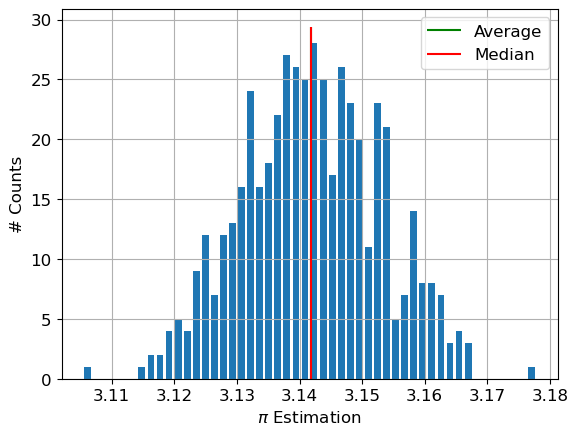

In [2]:
N = 10_000_000

# From one population
estim_1pop = estimate_pi.estim_pi_one_pop(N)

print(f'Estimated pi value for {N} samples over a single population:')
print(f'\t{round(estim_1pop, 6)}\n')

# From multiple population
N_pop = 500
estim_m_pop, populations = estimate_pi.estim_pi_multi_pop(N//N_pop, # if no: N//N_pop, unfair comparison with estim_1pop.
                                                          N_pop,
                                                          return_populations=True)

print(f'Estimated pi value for {N//N_pop} samples over a {N_pop} populations:')
print(f'\tMean: {round(estim_m_pop["mean"], 6)} +- {round(estim_m_pop["std"], 6)}')
print(f'\tMedian: {round(estim_m_pop["median"], 6)} +- {round(estim_m_pop["std"], 6)}\n')

estimate_pi.show_distribution(populations, 50)

## Birthday problem

There are 1 birthday collision for a room of 23 people(s).

For 1000 room(s) with 23 people(s) each, there are 522 collision(s).
This make a probability to have a collision of ~0.522.
There is an average of ~0.702 collisions per room.



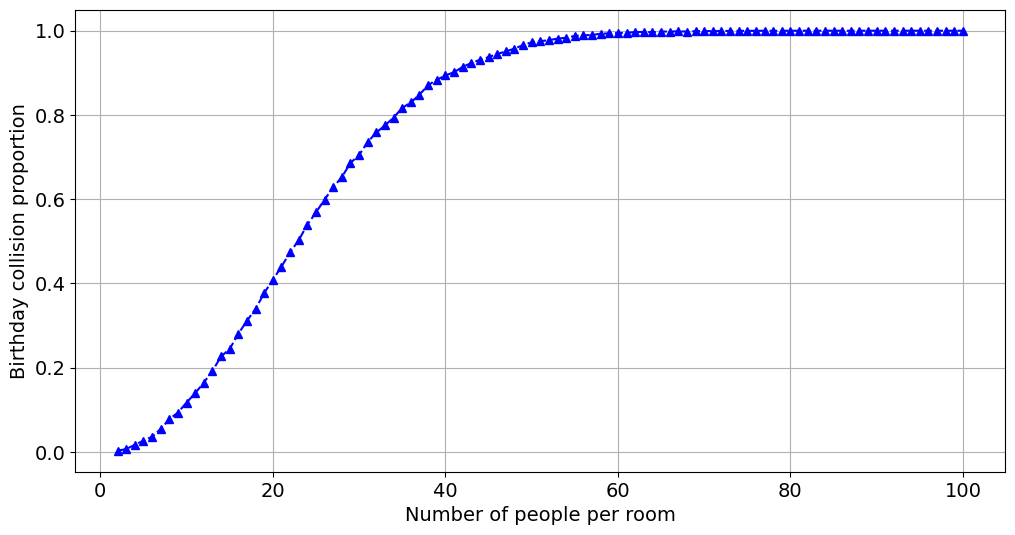

In [3]:
# Test with only one room
N = 23
res = birthday_problem.simulate_one_room(N)

if res > 0:
    print(f'There are {res} birthday collision for a room of {N} people(s).\n')
else:
    print(f'No birthday collision for a room of {N} people(s).\n')

# Look at distribution
n_room = 1_000
res = birthday_problem.simulate_multi_room(N, n_room)

distrib = np.bincount(res > 0, minlength=2)

print(f'For {n_room} room(s) with {N} people(s) each, there are {int(distrib[1])} collision(s).')
print(f'This make a probability to have a collision of ~{round(distrib[1]/n_room, 4)}.')
print(f'There is an average of ~{round(np.mean(res), 4)} collisions per room.\n')

# Evolution of collision probability per number of people per room
n_peoples = np.arange(2, 101)

n_room = 10_000

rates = birthday_problem.simulate_multi_room_people(n_peoples, n_room)
birthday_problem.show_rates_peoples(n_peoples, rates)


# Monty Hall

For 100000 test on the 3 doors case, win proportions are:
	33.398% if we keep the first chosen door.
	66.602% if we switch from the first chosen door.



100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [00:25<00:00, 19.65it/s]


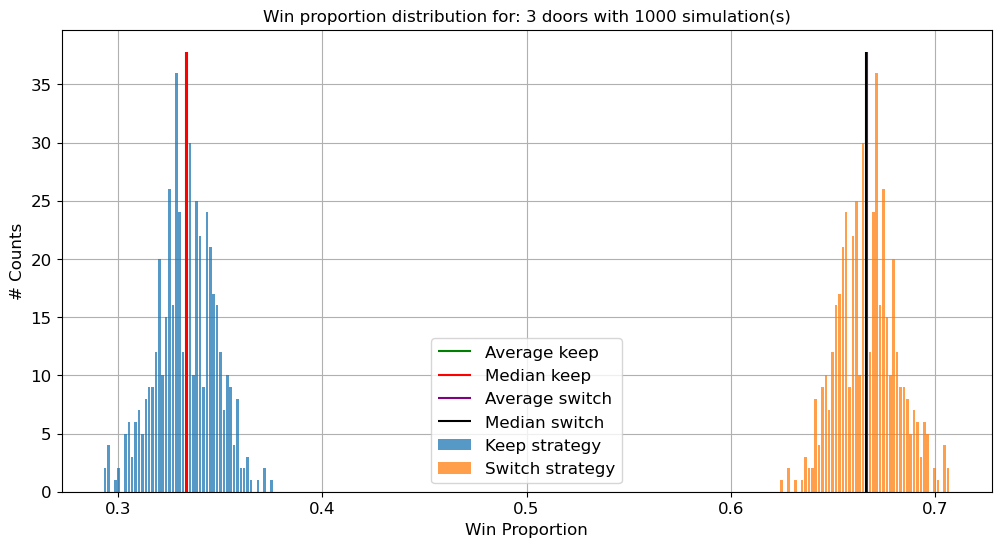

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [00:05<00:00,  1.58it/s]


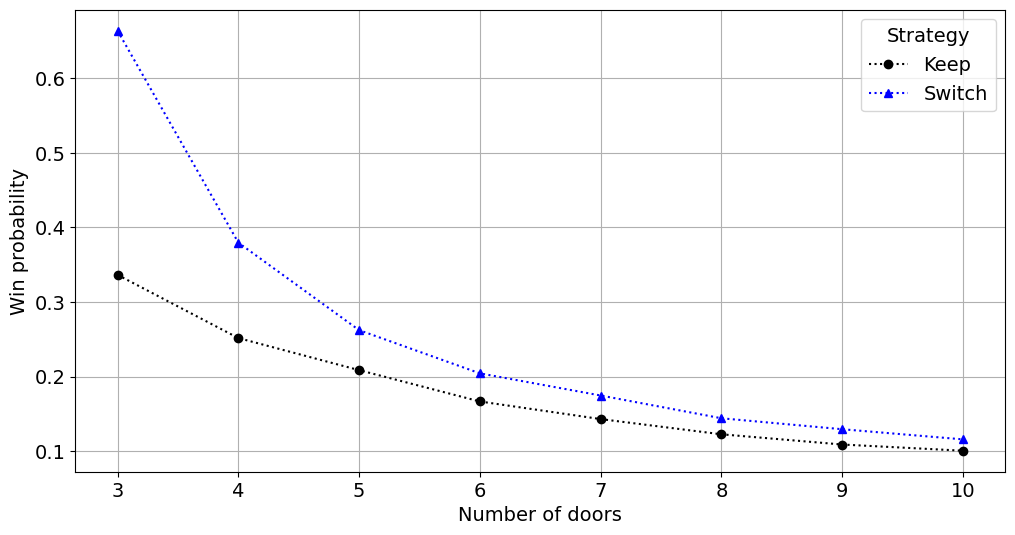

In [5]:
N = 100_000
n_door = 3

# Win proportion for the 3 doors
rates = monty_hall.simulations(N, n_door)

print(f'For {N} test on the {n_door} doors case, win proportions are:')
print(f'\t{round(float(rates[0]*100), 4)}% if we keep the first chosen door.')
print(f'\t{round(float(rates[1]*100), 4)}% if we switch from the first chosen door.\n')

# Look at distribution
N = 1_000
n_door = np.array([3]*500)
rates = monty_hall.multidoor_simulation(N, n_door)
monty_hall.distrib_one_case(rates, N, int(n_door[0]), 50)

# number of simulation per number of door
N = 10_000
n_door = np.arange(3, 11, 1)
rates = monty_hall.multidoor_simulation(N, n_door)
monty_hall.multidoor_simulation_plot(rates, n_door)